## Step 0 – Check GPU
Make sure you have a GPU runtime: **Runtime → Change runtime type → T4 GPU**

In [1]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('⚠️  No GPU found. Go to Runtime → Change runtime type → T4 GPU')

Using device: cuda
GPU: Tesla T4


## Step 1 – Import Libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2 – Hyperparameters
These are the settings that control how our model trains. You can tweak them later.

In [3]:
# ── Hyperparameters ──────────────────────────────────────────────
IMG_SIZE    = 32       # CIFAR-10 images are 32×32
BATCH_SIZE  = 128      # number of images processed at once
EPOCHS      = 15       # number of full passes through the training data
LR          = 2e-4     # learning rate for the optimizer
L1_WEIGHT   = 10.0     # how much to weight L1 loss vs MSE loss
NUM_WORKERS = 2        # parallel data loading threads

print(f'Training for {EPOCHS} epochs with batch size {BATCH_SIZE}')
print(f'Estimated training time on T4 GPU: ~10-15 minutes')

Training for 15 epochs with batch size 128
Estimated training time on T4 GPU: ~10-15 minutes


## Task 1 – Load Paired Images

We create **pairs**: the input (X) is the grayscale version of a CIFAR-10 image, and the target (Y) is the original colour image.

```
Input  X  →  [Grayscale image: 1 channel]
Target Y  →  [Colour image:    3 channels]
```

In [4]:
class PairedCIFAR10(Dataset):
    """
    Wraps CIFAR-10 to produce (grayscale, colour) image pairs.
    - X (input)  : grayscale image, 1 channel,  range [-1, 1]
    - Y (target) : colour image,    3 channels, range [-1, 1]
    """
    def __init__(self, train=True):
        # Download CIFAR-10 and apply normalization to [-1, 1]
        self.colour_transform = transforms.Compose([
            transforms.ToTensor(),                          # [0,255] → [0,1]
            transforms.Normalize((0.5,)*3, (0.5,)*3)       # [0,1]   → [-1,1]
        ])
        self.dataset = torchvision.datasets.CIFAR10(
            root='./data', train=train,
            download=True, transform=self.colour_transform
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        colour_img, label = self.dataset[idx]    # shape: [3, 32, 32], range [-1,1]

        # Convert to grayscale: average the 3 colour channels → 1 channel
        # This simulates "losing" colour information (the input to our model)
        gray_img = colour_img.mean(dim=0, keepdim=True)   # shape: [1, 32, 32]

        return gray_img, colour_img   # (input X, target Y)


# Create datasets
print('Downloading CIFAR-10 dataset...')
train_dataset = PairedCIFAR10(train=True)
val_dataset   = PairedCIFAR10(train=False)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Training samples : {len(train_dataset):,}')
print(f'Validation samples: {len(val_dataset):,}')
print(f'Train batches    : {len(train_loader)}')
print(f'Input shape      : {train_dataset[0][0].shape}  (grayscale)')
print(f'Target shape     : {train_dataset[0][1].shape}  (colour)')

100%|██████████| 170M/170M [00:04<00:00, 42.2MB/s]


Training samples : 50,000
Validation samples: 10,000
Train batches    : 391
Input shape      : torch.Size([1, 32, 32])  (grayscale)
Target shape     : torch.Size([3, 32, 32])  (colour)


### Visualize Sample Pairs
Let's see what our input/target pairs look like before training.

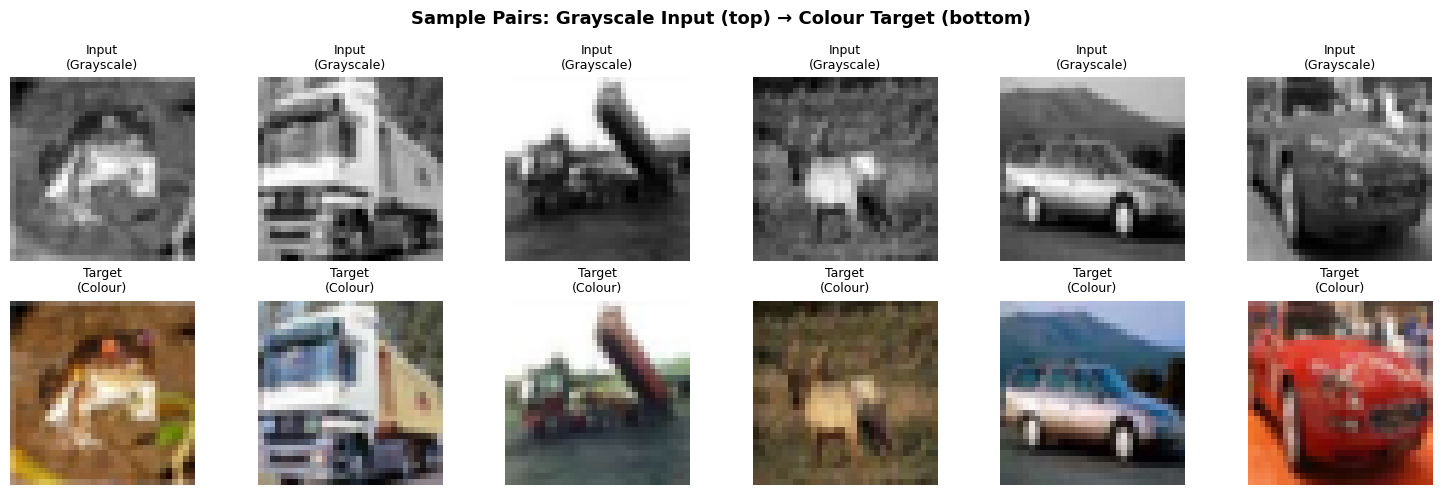

The model must learn to ADD colour from grayscale images.


In [5]:
def denormalize(tensor):
    """Convert tensor from [-1,1] back to [0,1] for display."""
    return (tensor * 0.5 + 0.5).clamp(0, 1)

# Show 6 input-target pairs
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
fig.suptitle('Sample Pairs: Grayscale Input (top) → Colour Target (bottom)',
             fontsize=13, fontweight='bold')

for i in range(6):
    gray, colour = train_dataset[i]

    # Top row: grayscale input
    axes[0, i].imshow(denormalize(gray).squeeze(), cmap='gray')
    axes[0, i].set_title('Input\n(Grayscale)', fontsize=9)
    axes[0, i].axis('off')

    # Bottom row: colour target
    axes[1, i].imshow(denormalize(colour).permute(1, 2, 0))
    axes[1, i].set_title('Target\n(Colour)', fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('sample_pairs.png', dpi=100, bbox_inches='tight')
plt.show()
print('The model must learn to ADD colour from grayscale images.')

## Task 2 – Normalization is already done! ✅

In the dataset above, we applied:
```
transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
```
This maps pixel values from **[0, 1] → [-1, 1]**, which is standard for image generation models.

Let's verify:

In [6]:
# Verify normalization range
sample_gray, sample_colour = train_dataset[0]

print('=== Task 2: Normalization Verification ===')
print(f'Grayscale input  – min: {sample_gray.min():.3f}, max: {sample_gray.max():.3f}')
print(f'Colour target    – min: {sample_colour.min():.3f}, max: {sample_colour.max():.3f}')
print('Both are in range [-1, 1] ✓')

=== Task 2: Normalization Verification ===
Grayscale input  – min: -1.000, max: 0.935
Colour target    – min: -1.000, max: 1.000
Both are in range [-1, 1] ✓


## Task 3 – Build the Encoder–Decoder CNN

### Architecture Overview
```
INPUT (1×32×32 grayscale)
        ↓
   [ENCODER]  — compresses image into a small feature map
   Conv 1×32×32  → 64×32×32
   Conv 64×32×32 → 128×16×16  (stride 2 = halve size)
   Conv 128×16×16 → 256×8×8   (stride 2 = halve size)
        ↓
   [BOTTLENECK]  — learns compact representation
   Conv 256×8×8  → 256×8×8
        ↓
   [DECODER]  — expands back to original size
   ConvTranspose 256×8×8  → 128×16×16  (upsample)
   ConvTranspose 128×16×16 → 64×32×32  (upsample)
   Conv 64×32×32 → 3×32×32  (output: 3-channel colour)
        ↓
OUTPUT (3×32×32 colour image)
```

In [7]:
class EncoderDecoderCNN(nn.Module):
    """
    Baseline Encoder-Decoder CNN for grayscale → colour translation.

    Encoder: progressively reduces spatial size, increases channels
    Bottleneck: processes compressed representation
    Decoder: progressively increases spatial size, reduces channels
    """
    def __init__(self):
        super().__init__()

        # ── ENCODER ──────────────────────────────────────────────
        # Each block: Conv → BatchNorm → LeakyReLU
        # stride=2 halves the spatial dimensions (like a pooling layer)
        self.enc1 = self._enc_block(1,   64,  stride=1)   # 1×32×32  → 64×32×32
        self.enc2 = self._enc_block(64,  128, stride=2)   # 64×32×32 → 128×16×16
        self.enc3 = self._enc_block(128, 256, stride=2)   # 128×16×16→ 256×8×8

        # ── BOTTLENECK ────────────────────────────────────────────
        # Deepest layer: processes the compressed features
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        # ── DECODER ──────────────────────────────────────────────
        # ConvTranspose2d is the "reverse" of Conv2d — it upsamples
        # stride=2 doubles the spatial dimensions
        self.dec1 = self._dec_block(256, 128, stride=2)   # 256×8×8  → 128×16×16
        self.dec2 = self._dec_block(128, 64,  stride=2)   # 128×16×16→ 64×32×32

        # ── OUTPUT LAYER ─────────────────────────────────────────
        # Final conv to produce 3-channel colour output
        # Tanh squashes output to [-1, 1] to match our target range
        self.output_layer = nn.Sequential(
            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def _enc_block(self, in_ch, out_ch, stride):
        """One encoder block: Conv → BN → LeakyReLU"""
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3,
                      stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def _dec_block(self, in_ch, out_ch, stride):
        """One decoder block: ConvTranspose → BN → ReLU"""
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4,
                               stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encode (compress)
        e1 = self.enc1(x)           # 64×32×32
        e2 = self.enc2(e1)          # 128×16×16
        e3 = self.enc3(e2)          # 256×8×8

        # Bottleneck
        b  = self.bottleneck(e3)    # 256×8×8

        # Decode (expand)
        d1 = self.dec1(b)           # 128×16×16
        d2 = self.dec2(d1)          # 64×32×32

        # Output
        out = self.output_layer(d2) # 3×32×32
        return out


# Instantiate the model and move to GPU
model = EncoderDecoderCNN().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('=== Task 3: Encoder–Decoder CNN ===')
print(model)
print(f'\nTotal parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

=== Task 3: Encoder–Decoder CNN ===
EncoderDecoderCNN(
  (enc1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (enc3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (bottleneck): Sequential(
    (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_r

## Task 4 – Define Losses and Train

### Loss Functions
We use a **combined loss** = MSE Loss + λ × L1 Loss:

| Loss | Formula | Effect |
|------|---------|--------|
| **MSE** | mean((pred - target)²) | Penalizes large errors heavily, leads to blurry outputs |
| **L1**  | mean(\|pred - target\|) | Penalizes all errors equally, slightly sharper |
| **Combined** | MSE + λ·L1 | Balance between both |

> **Why blurry?** Both MSE and L1 minimize average error. For uncertain pixels (e.g., what colour is the sky?), the safest average prediction is a grey/muted value — hence blur.

In [8]:
# ── Loss functions ────────────────────────────────────────────────
mse_loss = nn.MSELoss()
l1_loss  = nn.L1Loss()

# ── Optimizer ─────────────────────────────────────────────────────
# Adam with β1=0.5 (standard for image generation tasks)
optimizer = optim.Adam(model.parameters(), lr=LR, betas=(0.5, 0.999))

# ── Learning rate scheduler ───────────────────────────────────────
# Reduce LR by half every 5 epochs to help convergence
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print('Loss functions and optimizer ready!')
print(f'Optimizer : Adam (lr={LR}, β1=0.5, β2=0.999)')
print(f'Scheduler : StepLR (step=5, gamma=0.5)')
print(f'Combined loss = MSE + {L1_WEIGHT} × L1')

Loss functions and optimizer ready!
Optimizer : Adam (lr=0.0002, β1=0.5, β2=0.999)
Scheduler : StepLR (step=5, gamma=0.5)
Combined loss = MSE + 10.0 × L1


In [9]:
def train_one_epoch(model, loader, optimizer):
    """Run one full pass over the training data."""
    model.train()
    total_mse, total_l1, total_combined = 0.0, 0.0, 0.0

    for gray, colour in loader:
        gray   = gray.to(device)
        colour = colour.to(device)

        # Forward pass
        pred = model(gray)

        # Compute losses
        loss_mse = mse_loss(pred, colour)
        loss_l1  = l1_loss(pred, colour)
        loss     = loss_mse + L1_WEIGHT * loss_l1

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_mse      += loss_mse.item()
        total_l1       += loss_l1.item()
        total_combined += loss.item()

    n = len(loader)
    return total_mse/n, total_l1/n, total_combined/n


@torch.no_grad()
def validate(model, loader):
    """Evaluate the model on the validation set."""
    model.eval()
    total_mse, total_l1 = 0.0, 0.0

    for gray, colour in loader:
        gray   = gray.to(device)
        colour = colour.to(device)
        pred   = model(gray)
        total_mse += mse_loss(pred, colour).item()
        total_l1  += l1_loss(pred,  colour).item()

    n = len(loader)
    return total_mse/n, total_l1/n


print('Training functions defined. Starting training...')
print('='*60)

Training functions defined. Starting training...


In [10]:
# ── Training Loop ─────────────────────────────────────────────────
history = {'train_mse': [], 'train_l1': [], 'val_mse': [], 'val_l1': []}

print(f'Training for {EPOCHS} epochs on {device}...')
print(f'{'Epoch':>6} | {'Train MSE':>10} | {'Train L1':>10} | {'Val MSE':>9} | {'Val L1':>8} | {'LR':>8}')
print('-'*62)

for epoch in range(1, EPOCHS + 1):
    # Train
    tr_mse, tr_l1, tr_comb = train_one_epoch(model, train_loader, optimizer)

    # Validate
    val_mse, val_l1 = validate(model, val_loader)

    # Update learning rate
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # Store history
    history['train_mse'].append(tr_mse)
    history['train_l1'].append(tr_l1)
    history['val_mse'].append(val_mse)
    history['val_l1'].append(val_l1)

    print(f'{epoch:>6} | {tr_mse:>10.4f} | {tr_l1:>10.4f} | {val_mse:>9.4f} | {val_l1:>8.4f} | {current_lr:>8.6f}')

print('-'*62)
print('Training complete!')

Training for 15 epochs on cuda...
 Epoch |  Train MSE |   Train L1 |   Val MSE |   Val L1 |       LR
--------------------------------------------------------------
     1 |     0.0305 |     0.1225 |    0.0225 |   0.1045 | 0.000200
     2 |     0.0225 |     0.1048 |    0.0216 |   0.1020 | 0.000200
     3 |     0.0216 |     0.1017 |    0.0206 |   0.0991 | 0.000200
     4 |     0.0211 |     0.1000 |    0.0202 |   0.0960 | 0.000200
     5 |     0.0208 |     0.0989 |    0.0204 |   0.0972 | 0.000100
     6 |     0.0201 |     0.0964 |    0.0193 |   0.0929 | 0.000100
     7 |     0.0201 |     0.0964 |    0.0193 |   0.0940 | 0.000100
     8 |     0.0201 |     0.0963 |    0.0194 |   0.0940 | 0.000100
     9 |     0.0199 |     0.0956 |    0.0199 |   0.0954 | 0.000100
    10 |     0.0198 |     0.0951 |    0.0190 |   0.0927 | 0.000050
    11 |     0.0194 |     0.0937 |    0.0190 |   0.0921 | 0.000050
    12 |     0.0193 |     0.0936 |    0.0190 |   0.0918 | 0.000050
    13 |     0.0193 |     0.0933

### Plot Training Curves

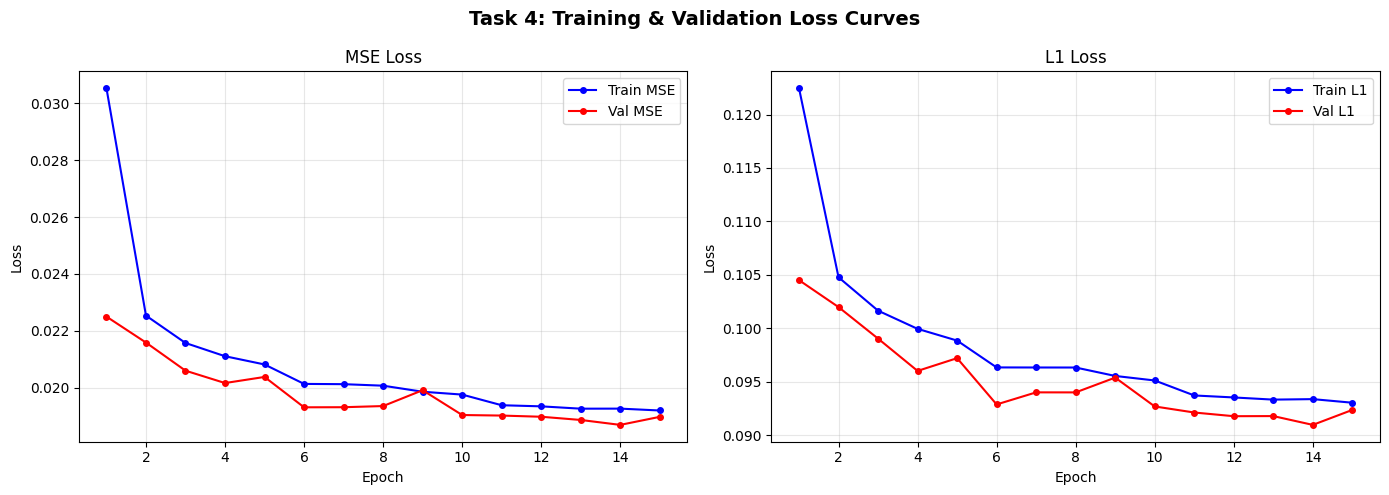

Final Train MSE : 0.0192
Final Val   MSE : 0.0190
Final Train L1  : 0.0931
Final Val   L1  : 0.0924


In [11]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 4: Training & Validation Loss Curves', fontsize=14, fontweight='bold')

# MSE Loss
axes[0].plot(epochs_range, history['train_mse'], 'b-o', markersize=4, label='Train MSE')
axes[0].plot(epochs_range, history['val_mse'],   'r-o', markersize=4, label='Val MSE')
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# L1 Loss
axes[1].plot(epochs_range, history['train_l1'], 'b-o', markersize=4, label='Train L1')
axes[1].plot(epochs_range, history['val_l1'],   'r-o', markersize=4, label='Val L1')
axes[1].set_title('L1 Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Final Train MSE : {history["train_mse"][-1]:.4f}')
print(f'Final Val   MSE : {history["val_mse"][-1]:.4f}')
print(f'Final Train L1  : {history["train_l1"][-1]:.4f}')
print(f'Final Val   L1  : {history["val_l1"][-1]:.4f}')

## Task 5 – Visualize Translated Images

Now let's see what our trained model actually produces!

We show three rows:
- **Row 1** – Grayscale input (what the model sees)
- **Row 2** – Model prediction (colorized output)
- **Row 3** – Ground truth (original colour image)

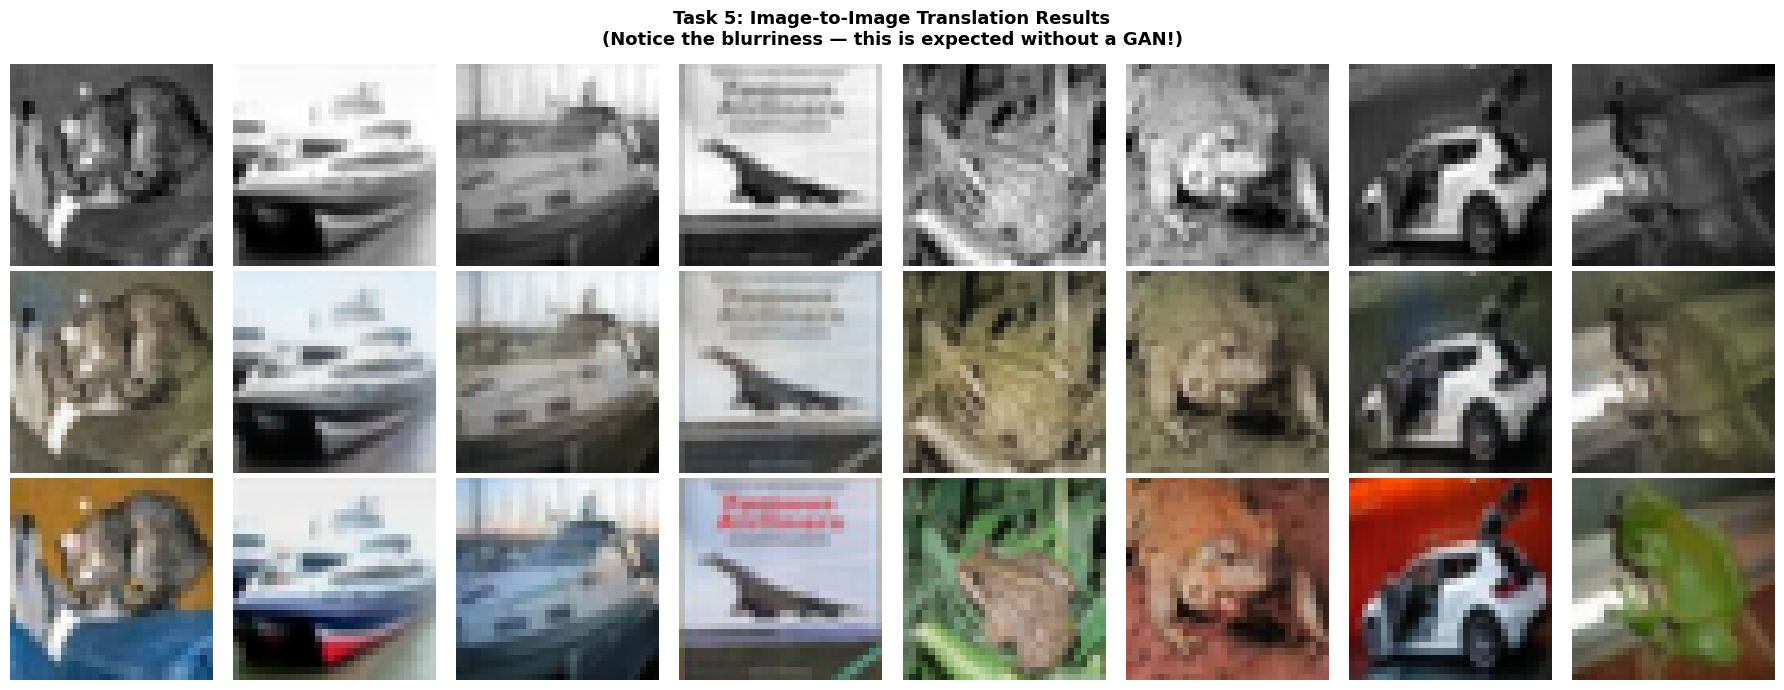

Visualization saved as translation_results.png


In [12]:
model.eval()

# Get a batch from the validation set
gray_batch, colour_batch = next(iter(val_loader))
gray_batch   = gray_batch.to(device)
colour_batch = colour_batch.to(device)

with torch.no_grad():
    pred_batch = model(gray_batch)

# Move back to CPU for plotting
gray_batch   = gray_batch.cpu()
colour_batch = colour_batch.cpu()
pred_batch   = pred_batch.cpu()

# ── Plot: 8 samples ───────────────────────────────────────────────
n_show = 8
fig, axes = plt.subplots(3, n_show, figsize=(18, 7))
fig.suptitle('Task 5: Image-to-Image Translation Results\n(Notice the blurriness — this is expected without a GAN!)',
             fontsize=13, fontweight='bold')

row_labels = ['Input\n(Grayscale)', 'Prediction\n(Our CNN)', 'Ground Truth\n(Colour)']

for i in range(n_show):
    # Row 0: Grayscale input
    axes[0, i].imshow(denormalize(gray_batch[i]).squeeze(), cmap='gray')
    axes[0, i].axis('off')

    # Row 1: Predicted colourization
    axes[1, i].imshow(denormalize(pred_batch[i]).permute(1, 2, 0))
    axes[1, i].axis('off')

    # Row 2: Ground truth colour
    axes[2, i].imshow(denormalize(colour_batch[i]).permute(1, 2, 0))
    axes[2, i].axis('off')

# Add row labels on the left
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=10, fontweight='bold',
                            rotation=0, labelpad=60, va='center')

plt.tight_layout()
plt.savefig('translation_results.png', dpi=100, bbox_inches='tight')
plt.show()

print('Visualization saved as translation_results.png')

## Final Summary & Analysis

In [13]:
             # ── Compute final metrics on the full validation set ──────────────
val_mse_final, val_l1_final = validate(model, val_loader)

print('=' * 55)
print('       CSET419 Lab 5 – Results Summary')
print('=' * 55)
print(f'  Task 1 : Dataset     CIFAR-10 (grayscale → colour pairs)')
print(f'  Task 2 : Norm range  [-1, 1]  ✓')
print(f'  Task 3 : Model       Encoder–Decoder CNN')
print(f'           Parameters  {sum(p.numel() for p in model.parameters()):,}')
print(f'  Task 4 : Final MSE   {val_mse_final:.4f}')
print(f'           Final L1    {val_l1_final:.4f}')
print(f'  Task 5 : Outputs     Blurry (as expected)')
print('=' * 55)
print()
print('WHY ARE THE OUTPUTS BLURRY?')
print('-' * 55)
print('The CNN minimizes average pixel error (MSE/L1).')
print('When multiple colours are plausible for a region,')
print('the "safest" average prediction is a muted/grey value.')
print('This is the fundamental limitation of pixel-wise loss.')
print()
print('HOW DO GANS FIX THIS? (Preview for Lab 6)')
print('-' * 55)
print('A GAN adds a Discriminator that learns to detect blurry')
print('outputs and pushes the Generator to produce sharp, realistic')
print('images — not just low-error averages.')

       CSET419 Lab 5 – Results Summary
  Task 1 : Dataset     CIFAR-10 (grayscale → colour pairs)
  Task 2 : Norm range  [-1, 1]  ✓
  Task 3 : Model       Encoder–Decoder CNN
           Parameters  1,618,179
  Task 4 : Final MSE   0.0190
           Final L1    0.0924
  Task 5 : Outputs     Blurry (as expected)

WHY ARE THE OUTPUTS BLURRY?
-------------------------------------------------------
The CNN minimizes average pixel error (MSE/L1).
When multiple colours are plausible for a region,
the "safest" average prediction is a muted/grey value.
This is the fundamental limitation of pixel-wise loss.

HOW DO GANS FIX THIS? (Preview for Lab 6)
-------------------------------------------------------
A GAN adds a Discriminator that learns to detect blurry
outputs and pushes the Generator to produce sharp, realistic
images — not just low-error averages.
